In [36]:
# ============================================================
# 1. IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import statsmodels.api as sm

# XGBoost
try:
    from xgboost import XGBClassifier
    xgboost_available = True
except ImportError:
    xgboost_available = False
    print("XGBoost is not installed. GradientBoostingClassifier will be used instead.")

In [37]:
# ============================================================
# 2. DATA PREPARATION + FEATURE ENGINEERING
# ============================================================

data = pd.read_excel('data/working_dataset.xlsx')

target = 'DEFAUT'

# ------------------------------------------------------------
# 2.1 Date variables
# ------------------------------------------------------------

data['DATE_OPERATION'] = pd.to_datetime(data['DATE_OPERATION'], errors='coerce')

data['ANNEE_OPERATION'] = data['DATE_OPERATION'].dt.year
data['MOIS_OPERATION'] = data['DATE_OPERATION'].dt.month

# Périodes de prêt proposées par l'encadrant
data['PERIODE_PRET'] = pd.cut(
    data['ANNEE_OPERATION'],
    bins=[2012, 2016, 2020, 2025],
    labels=[
        'Prêts anciens_2013_2016',
        'Prêts intermédiaires_2017_2020',
        'Prêts récents_2021_2025'
    ],
    include_lowest=True
)

# ------------------------------------------------------------
# 2.2 New grouped variables
# ------------------------------------------------------------

data['CLASSE_MONTANT'] = pd.qcut(
    data['MONTANT'],
    q=4,
    labels=['Montant faible', 'Montant moyen-faible', 'Montant moyen-élevé', 'Montant élevé'],
    duplicates='drop'
)

data['CLASSE_DUREE'] = pd.cut(
    data['DUREE'],
    bins=[0, 12, 36, 60, 120],
    labels=['Courte durée', 'Durée moyenne', 'Durée longue', 'Très longue durée'],
    include_lowest=True
)

data['CLASSE_AGE'] = pd.cut(
    data['AGE'],
    bins=[0, 34, 44, 54, 64, 120],
    labels=['Moins de 35', '35-44', '45-54', '55-64', '65 et plus'],
    include_lowest=True
)

# Drop raw date
data = data.drop(columns=['DATE_OPERATION'], errors='ignore')

# ------------------------------------------------------------
# 2.3 Remove leakage variables
# ------------------------------------------------------------

variables_to_drop = [
    'NBIMP',
    'IMPAYE',
    'MNTREMB',
    'NB_ECH'
]

data = data.drop(columns=variables_to_drop, errors='ignore')

# ------------------------------------------------------------
# 2.4 Separate X and y
# ------------------------------------------------------------

X = data.drop(columns=[target])
y = data[target]

print("Shape of X:", X.shape)

print("\nDistribution of DEFAUT:")
print(y.value_counts())

print("\nDistribution of DEFAUT (%):")
print(y.value_counts(normalize=True).mul(100).round(2))

Shape of X: (25680, 19)

Distribution of DEFAUT:
DEFAUT
1    13249
0    12431
Name: count, dtype: int64

Distribution of DEFAUT (%):
DEFAUT
1    51.59
0    48.41
Name: proportion, dtype: float64


In [38]:
# ============================================================
# 3. TRAIN / DEVELOPMENT / TEST SPLIT
# ============================================================

# First split: 60% train, 40% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=42,
    stratify=y
)

# Second split: 20% development, 20% test
X_dev, X_test, y_dev, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("X_train:", X_train.shape)
print("X_dev  :", X_dev.shape)
print("X_test :", X_test.shape)

print("\nDistribution train:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nDistribution development:")
print(y_dev.value_counts(normalize=True).mul(100).round(2))

print("\nDistribution test:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

X_train: (15408, 19)
X_dev  : (5136, 19)
X_test : (5136, 19)

Distribution train:
DEFAUT
1    51.59
0    48.41
Name: proportion, dtype: float64

Distribution development:
DEFAUT
1    51.6
0    48.4
Name: proportion, dtype: float64

Distribution test:
DEFAUT
1    51.6
0    48.4
Name: proportion, dtype: float64


In [39]:
# ============================================================
# 4. PREPROCESSING
# ============================================================

# Automatically detect numerical and categorical variables

numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=['object', 'string', 'category', 'bool']
).columns.tolist()

print("Numerical variables:")
print(numeric_features)

print("\nCategorical variables:")
print(categorical_features)


# ------------------------------------------------------------
# 4.1 Numerical preprocessing
# ------------------------------------------------------------
# Median imputation:
# Financial variables often contain extreme values.
# The median is more robust than the mean.
#
# StandardScaler:
# Needed for logistic regression because it is sensitive to scale.
# It is not necessary for trees, but using it inside the same pipeline
# keeps the workflow clean and does not harm the tree models.

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


# ------------------------------------------------------------
# 4.2 Categorical preprocessing
# ------------------------------------------------------------
# Most frequent imputation:
# Used to replace missing categorical values.
#
# OneHotEncoder:
# Converts categorical variables into numerical binary columns.
# handle_unknown='ignore' prevents errors if a new category appears in test data.

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])


# ------------------------------------------------------------
# 4.3 Full preprocessor
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

Numerical variables:
['MONTANT', 'DUREE', 'TAUX_INT', 'AGE']

Categorical variables:
['INDLIB_GROUPE', 'PORTEF', 'PERIODE', 'SEX', 'A_GARANTIE', 'AGENCE_LIEU', 'ETATCIVIL', 'WILAYA_NAISSANCE', 'TYPE_CLIENT', 'PERIODE_PRET', 'CLASSE_MONTANT', 'CLASSE_DUREE', 'CLASSE_AGE']


In [40]:
# ============================================================
# 6. BASELINE LOGISTIC REGRESSION WITHOUT PENALIZATION
#    Backward selection using p-values
# ============================================================

# Fit preprocessing only on train data
X_train_processed = preprocessor.fit_transform(X_train)
X_dev_processed = preprocessor.transform(X_dev)
X_test_processed = preprocessor.transform(X_test)

# Convert to dense matrix if needed
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
    X_dev_processed = X_dev_processed.toarray()
    X_test_processed = X_test_processed.toarray()

# Get feature names
numeric_names = preprocessor.named_transformers_['num'].get_feature_names_out(numeric_features)

categorical_names = (
    preprocessor
    .named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names_out(categorical_features)
)

feature_names = np.concatenate([numeric_names, categorical_names])

X_train_logit = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_dev_logit = pd.DataFrame(X_dev_processed, columns=feature_names, index=X_dev.index)
X_test_logit = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)

# Add constant
X_train_logit_const = sm.add_constant(X_train_logit, has_constant='add')

# Backward selection
selected_features = list(X_train_logit_const.columns)

while True:
    model_logit = sm.Logit(y_train, X_train_logit_const[selected_features]).fit(disp=False)
    pvalues = model_logit.pvalues.drop('const', errors='ignore')
    
    max_pvalue = pvalues.max()
    
    if max_pvalue > 0.05:
        worst_feature = pvalues.idxmax()
        selected_features.remove(worst_feature)
        print("Removed:", worst_feature, "| p-value:", round(max_pvalue, 4))
    else:
        break

# Final logistic model
final_logit = sm.Logit(y_train, X_train_logit_const[selected_features]).fit(disp=False)

print(final_logit.summary())

c:\Users\delli7\Desktop\PFE\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Removed: CLASSE_AGE_Moins de 35 | p-value: 1.0


c:\Users\delli7\Desktop\PFE\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Removed: PERIODE_PRET_Prêts intermédiaires_2017_2020 | p-value: 1.0


c:\Users\delli7\Desktop\PFE\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...

Removed: PORTEF_CAM | p-value: 1.0


c:\Users\delli7\Desktop\PFE\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Removed: CLASSE_DUREE_Durée longue | p-value: 1.0


c:\Users\delli7\Desktop\PFE\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Removed: A_GARANTIE_Non | p-value: 0.9913
Removed: ETATCIVIL_Single | p-value: 0.9321
Removed: TYPE_CLIENT_Public | p-value: 1.0
Removed: WILAYA_NAISSANCE_Inconnu | p-value: 0.9292
Removed: SEX_Female | p-value: 1.0
Removed: DUREE | p-value: 0.8874
Removed: MONTANT | p-value: 0.8641
Removed: TAUX_INT | p-value: 0.8377
Removed: WILAYA_NAISSANCE_Gorgol | p-value: 0.8116
Removed: AGENCE_LIEU_Tagant | p-value: 0.7851
Removed: AGENCE_LIEU_Trarza | p-value: 0.8724
Removed: WILAYA_NAISSANCE_Adrar | p-value: 0.6919
Removed: INDLIB_GROUPE_Services | p-value: 0.6802
Removed: CLASSE_AGE_55-64 | p-value: 0.6717
Removed: CLASSE_AGE_45-54 | p-value: 0.8968
Removed: CLASSE_AGE_65 et plus | p-value: 0.8202
Removed: INDLIB_GROUPE_Autres | p-value: 0.6727
Removed: CLASSE_MONTANT_Montant faible | p-value: 0.636
Removed: WILAYA_NAISSANCE_Hodh el Gharbi | p-value: 0.562
Removed: INDLIB_GROUPE_Transport | p-value: 0.5336
Removed: ETATCIVIL_Divorced | p-value: 0.4888
Removed: INDLIB_GROUPE_BTP/Construction |

In [41]:
# ============================================================
# 7. EVALUATE BASELINE LOGISTIC REGRESSION
# ============================================================

def evaluate_from_proba(model_name, y_true, y_proba, threshold=0.50):
    
    y_pred = (y_proba >= threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    specificity = tn / (tn + fp)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)
    
    print("=" * 80)
    print(model_name)
    print("=" * 80)
    print("Accuracy   :", round(accuracy, 4))
    print("Precision  :", round(precision, 4))
    print("Recall     :", round(recall, 4))
    print("Specificity:", round(specificity, 4))
    print("F1-score   :", round(f1, 4))
    print("ROC-AUC    :", round(auc, 4))
    print("\nConfusion matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification report:")
    print(classification_report(y_true, y_pred))
    
    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall/Sensitivity": recall,
        "Specificity": specificity,
        "F1-score": f1,
        "ROC-AUC": auc,
        "Threshold": threshold
    }

# Prepare dev and test with selected features
X_dev_logit_const = sm.add_constant(X_dev_logit, has_constant='add')
X_test_logit_const = sm.add_constant(X_test_logit, has_constant='add')

# Predicted probabilities
y_dev_proba_logit = final_logit.predict(X_dev_logit_const[selected_features])
y_test_proba_logit = final_logit.predict(X_test_logit_const[selected_features])

logit_dev_result = evaluate_from_proba(
    "Baseline Logistic Regression - Development",
    y_dev,
    y_dev_proba_logit
)

logit_test_result = evaluate_from_proba(
    "Baseline Logistic Regression - Test",
    y_test,
    y_test_proba_logit
)

Baseline Logistic Regression - Development
Accuracy   : 0.8431
Precision  : 0.8291
Recall     : 0.8766
Specificity: 0.8073
F1-score   : 0.8522
ROC-AUC    : 0.914

Confusion matrix:
[[2007  479]
 [ 327 2323]]

Classification report:
              precision    recall  f1-score   support

           0       0.86      0.81      0.83      2486
           1       0.83      0.88      0.85      2650

    accuracy                           0.84      5136
   macro avg       0.84      0.84      0.84      5136
weighted avg       0.84      0.84      0.84      5136

Baseline Logistic Regression - Test
Accuracy   : 0.839
Precision  : 0.8224
Recall     : 0.8774
Specificity: 0.7981
F1-score   : 0.849
ROC-AUC    : 0.9126

Confusion matrix:
[[1984  502]
 [ 325 2325]]

Classification report:
              precision    recall  f1-score   support

           0       0.86      0.80      0.83      2486
           1       0.82      0.88      0.85      2650

    accuracy                           0.84      5136

In [42]:
# ============================================================
# 5. DEFINE MACHINE LEARNING MODELS
# ============================================================

models = {
    "Logistic Regression L2": LogisticRegression(
        penalty='l2',
        C=1.0,
        max_iter=2000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        criterion='gini',
        max_depth=6,
        min_samples_leaf=30,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        criterion='gini',
        max_depth=10,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    )
}

if xgboost_available:
    models["XGBoost"] = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )
else:
    models["Gradient Boosting"] = GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

In [43]:
# ============================================================
# 8. EVALUATION FUNCTION FOR ML MODELS
# ============================================================

def evaluate_model(model_name, model, X_data, y_data, dataset_name="Test", threshold=0.50):
    
    y_proba = model.predict_proba(X_data)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_data, y_pred).ravel()
    
    accuracy = accuracy_score(y_data, y_pred)
    precision = precision_score(y_data, y_pred)
    recall = recall_score(y_data, y_pred)
    specificity = tn / (tn + fp)
    f1 = f1_score(y_data, y_pred)
    auc = roc_auc_score(y_data, y_proba)
    
    print("=" * 80)
    print(f"{model_name} - {dataset_name}")
    print("=" * 80)
    print("Accuracy   :", round(accuracy, 4))
    print("Precision  :", round(precision, 4))
    print("Recall     :", round(recall, 4))
    print("Specificity:", round(specificity, 4))
    print("F1-score   :", round(f1, 4))
    print("ROC-AUC    :", round(auc, 4))
    print("\nConfusion matrix:")
    print(confusion_matrix(y_data, y_pred))
    print("\nClassification report:")
    print(classification_report(y_data, y_pred))
    
    return {
        "Model": model_name,
        "Dataset": dataset_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall/Sensitivity": recall,
        "Specificity": specificity,
        "F1-score": f1,
        "ROC-AUC": auc,
        "Threshold": threshold
    }

In [44]:
# ============================================================
# 7. CROSS-VALIDATION FUNCTION
# ============================================================

def cross_validation_scores(model_name, model, X_train, y_train):
    
    # StratifiedKFold keeps the same class proportions in each fold.
    # This is better for classification than simple KFold.
    
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )
    
    scoring = {
        'accuracy': 'accuracy',
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1',
        'roc_auc': 'roc_auc'
    }
    
    cv_results = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=True
    )
    
    print("=" * 80)
    print("Cross-validation:", model_name)
    print("=" * 80)
    
    print("CV Accuracy :", round(cv_results['test_accuracy'].mean(), 4), "+/-", round(cv_results['test_accuracy'].std(), 4))
    print("CV Precision:", round(cv_results['test_precision'].mean(), 4), "+/-", round(cv_results['test_precision'].std(), 4))
    print("CV Recall   :", round(cv_results['test_recall'].mean(), 4), "+/-", round(cv_results['test_recall'].std(), 4))
    print("CV F1-score :", round(cv_results['test_f1'].mean(), 4), "+/-", round(cv_results['test_f1'].std(), 4))
    print("CV ROC-AUC  :", round(cv_results['test_roc_auc'].mean(), 4), "+/-", round(cv_results['test_roc_auc'].std(), 4))
    
    return {
        "Model": model_name,
        "CV Accuracy Mean": cv_results['test_accuracy'].mean(),
        "CV Accuracy Std": cv_results['test_accuracy'].std(),
        "CV Precision Mean": cv_results['test_precision'].mean(),
        "CV Precision Std": cv_results['test_precision'].std(),
        "CV Recall Mean": cv_results['test_recall'].mean(),
        "CV Recall Std": cv_results['test_recall'].std(),
        "CV F1 Mean": cv_results['test_f1'].mean(),
        "CV F1 Std": cv_results['test_f1'].std(),
        "CV ROC-AUC Mean": cv_results['test_roc_auc'].mean(),
        "CV ROC-AUC Std": cv_results['test_roc_auc'].std()
    }

In [45]:
# ============================================================
# 9. TRAIN AND EVALUATE ML MODELS
# ============================================================

trained_models = {}
results_all = []

for model_name, classifier in models.items():
    
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', classifier)
    ])
    
    pipeline.fit(X_train, y_train)
    
    trained_models[model_name] = pipeline
    
    dev_result = evaluate_model(
        model_name,
        pipeline,
        X_dev,
        y_dev,
        dataset_name="Development"
    )
    
    test_result = evaluate_model(
        model_name,
        pipeline,
        X_test,
        y_test,
        dataset_name="Test"
    )
    
    results_all.append(dev_result)
    results_all.append(test_result)

c:\Users\delli7\Desktop\PFE\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Logistic Regression L2 - Development
Accuracy   : 0.8437
Precision  : 0.8306
Recall     : 0.8755
Specificity: 0.8097
F1-score   : 0.8525
ROC-AUC    : 0.9145

Confusion matrix:
[[2013  473]
 [ 330 2320]]

Classification report:
              precision    recall  f1-score   support

           0       0.86      0.81      0.83      2486
           1       0.83      0.88      0.85      2650

    accuracy                           0.84      5136
   macro avg       0.84      0.84      0.84      5136
weighted avg       0.84      0.84      0.84      5136

Logistic Regression L2 - Test
Accuracy   : 0.8401
Precision  : 0.8244
Recall     : 0.877
Specificity: 0.8009
F1-score   : 0.8499
ROC-AUC    : 0.9127

Confusion matrix:
[[1991  495]
 [ 326 2324]]

Classification report:
              precision    recall  f1-score   support

           0       0.86      0.80      0.83      2486
           1       0.82      0.88      0.85      2650

    accuracy                           0.84      5136
   macro 

In [46]:
# ============================================================
# 10. FINAL COMPARISON TABLE
# ============================================================

results_df = pd.DataFrame(results_all)

# Add logistic baseline results
results_df = pd.concat(
    [
        pd.DataFrame([logit_dev_result, logit_test_result]),
        results_df
    ],
    ignore_index=True
)

results_df.sort_values(
    by=['Dataset', 'ROC-AUC'],
    ascending=[True, False]
).round(4)

,Model,Accuracy,Precision,Recall/Sensitivity,Specificity,F1-score,ROC-AUC,Threshold,Dataset
8,XGBoost,0.8481,0.8339,0.8811,0.8130,0.8569,0.9214,0.5,Development
6,Random Forest,0.8448,0.8203,0.8955,0.7908,0.8562,0.9182,0.5,Development
2,Logistic Regression L2,0.8437,0.8306,0.8755,0.8097,0.8525,0.9145,0.5,Development
4,Decision Tree,0.8429,0.8176,0.8951,0.7872,0.8546,0.9097,0.5,Development
9,XGBoost,0.8460,0.8288,0.8842,0.8053,0.8556,0.9197,0.5,Test
7,Random Forest,0.8384,0.8106,0.8962,0.7767,0.8513,0.9151,0.5,Test
3,Logistic Regression L2,0.8401,0.8244,0.8770,0.8009,0.8499,0.9127,0.5,Test
5,Decision Tree,0.8302,0.8028,0.8894,0.7671,0.8439,0.9035,0.5,Test
0,Baseline Logistic Regression - Development,0.8431,0.8291,0.8766,0.8073,0.8522,0.9140,0.5,NaN
1,Baseline Logistic Regression - Test,0.8390,0.8224,0.8774,0.7981,0.8490,0.9126,0.5,NaN


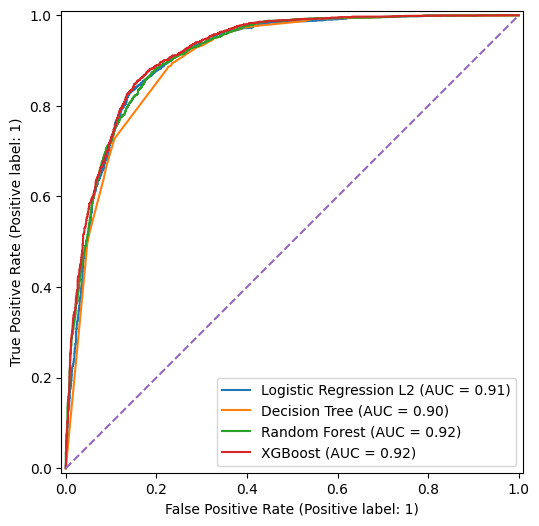

In [47]:
# ============================================================
# 11. ROC CURVES
# ============================================================

plt.figure(figsize=(8, 6))

ax = plt.gca()

for model_name, model in trained_models.items():
    
    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=model_name,
        ax=ax
    )

plt.plot([0, 1], [0, 1], linestyle='--')
# plt.title('Courbes ROC des modèles')
plt.show()

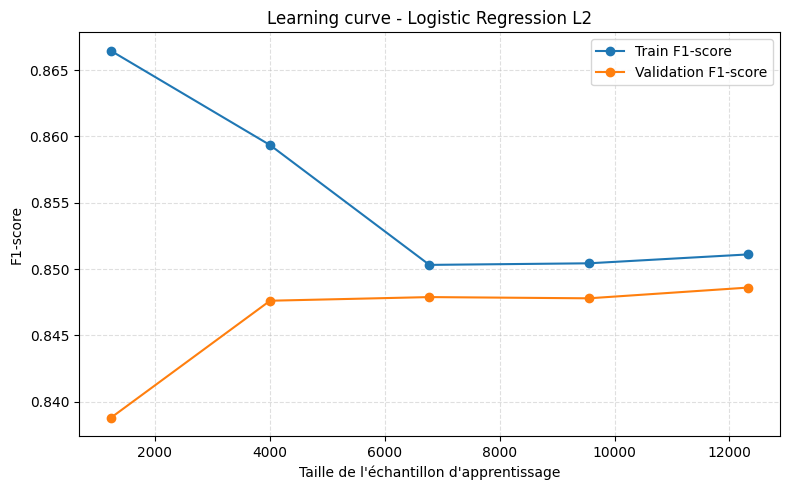

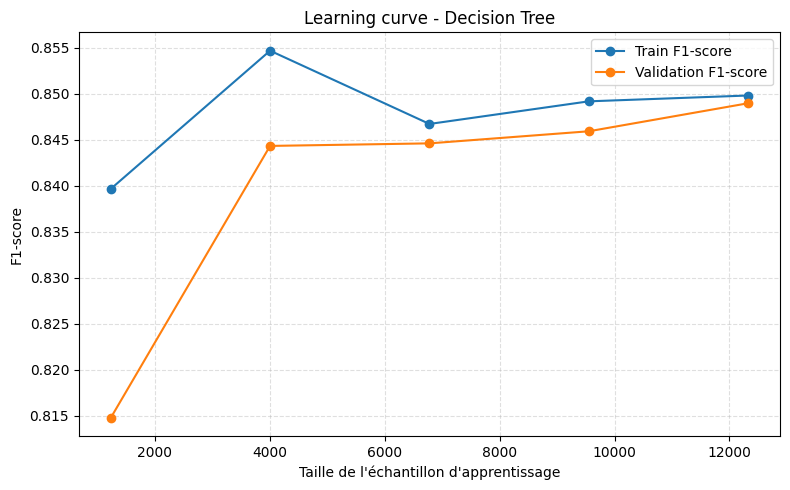

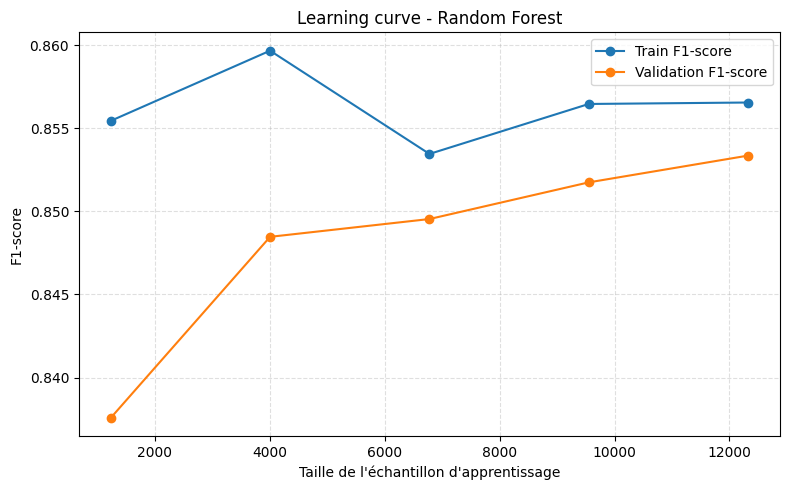

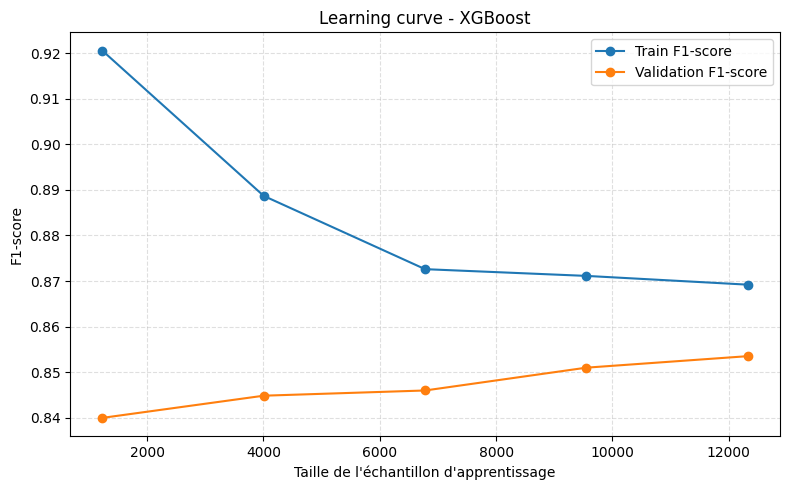

In [48]:
# ============================================================
# 12. LEARNING CURVES
# ============================================================
# Learning curves help diagnose overfitting and underfitting.
#
# If training score is high but validation score is much lower:
#    possible overfitting.
#
# If both training and validation scores are low:
#    possible underfitting.

from sklearn.model_selection import learning_curve

def plot_learning_curve(model, model_name, X_train, y_train):
    
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )
    
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='f1',
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5)
    )
    
    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)
    
    plt.figure(figsize=(8, 5))
    
    plt.plot(train_sizes, train_mean, marker='o', label='Train F1-score')
    plt.plot(train_sizes, val_mean, marker='o', label='Validation F1-score')
    
    plt.xlabel("Taille de l'échantillon d'apprentissage")
    plt.ylabel("F1-score")
    plt.title(f"Learning curve - {model_name}")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


for model_name, model in trained_models.items():
    plot_learning_curve(model, model_name, X_train, y_train)

In [49]:
# ============================================================
# 13. FEATURE IMPORTANCE FOR TREE-BASED MODELS
# ============================================================
# This is not a performance metric.
# It helps interpret which variables are important for the model.

def get_feature_names_from_preprocessor(preprocessor):
    
    numeric_names = preprocessor.named_transformers_['num'].get_feature_names_out(numeric_features)
    categorical_names = preprocessor.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(categorical_features)
    
    feature_names = np.concatenate([numeric_names, categorical_names])
    
    return feature_names


for model_name in ["Decision Tree", "Random Forest"]:
    
    model = trained_models[model_name]
    
    fitted_preprocessor = model.named_steps['preprocessor']
    classifier = model.named_steps['classifier']
    
    feature_names = get_feature_names_from_preprocessor(fitted_preprocessor)
    
    importances = classifier.feature_importances_
    
    importance_df = pd.DataFrame({
        'Variable': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)
    
    print("=" * 80)
    print("Feature importance:", model_name)
    print("=" * 80)
    display(importance_df.head(15))

Feature importance: Decision Tree


,Variable,Importance
1,DUREE,0.654091
15,PORTEF_PP,0.140968
49,WILAYA_NAISSANCE_Inconnu,0.052030
28,AGENCE_LIEU_Dakhlet Nouadhibou,0.036761
5,INDLIB_GROUPE_Autres,0.017031
57,PERIODE_PRET_Prêts anciens_2013_2016,0.014166
36,AGENCE_LIEU_Tiris Zemmour,0.013547
13,PORTEF_DDC,0.013368
0,MONTANT,0.010598
59,PERIODE_PRET_Prêts récents_2021_2025,0.009789


Feature importance: Random Forest


,Variable,Importance
1,DUREE,0.144892
64,CLASSE_DUREE_Courte durée,0.112375
66,CLASSE_DUREE_Durée moyenne,0.072875
11,PORTEF_CAM,0.064975
15,PORTEF_PP,0.063924
19,PERIODE_S,0.062833
18,PERIODE_M,0.053986
2,TAUX_INT,0.051100
0,MONTANT,0.039772
34,AGENCE_LIEU_Nouakchott,0.035834


In [50]:
# ============================================================
# 11. THRESHOLD OPTIMIZATION ON DEVELOPMENT SET
# ============================================================

best_model_name = results_df[
    results_df['Dataset'] == 'Development'
].sort_values('ROC-AUC', ascending=False).iloc[0]['Model']

print("Best model on development set:", best_model_name)

if best_model_name == "Baseline Logistic Regression - Development":
    y_dev_proba = y_dev_proba_logit
else:
    best_model = trained_models[best_model_name]
    y_dev_proba = best_model.predict_proba(X_dev)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.01)

threshold_results = []

for threshold in thresholds:
    
    y_pred_threshold = (y_dev_proba >= threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_dev, y_pred_threshold).ravel()
    
    threshold_results.append({
        'Threshold': threshold,
        'Accuracy': accuracy_score(y_dev, y_pred_threshold),
        'Precision': precision_score(y_dev, y_pred_threshold),
        'Recall/Sensitivity': recall_score(y_dev, y_pred_threshold),
        'Specificity': tn / (tn + fp),
        'F1-score': f1_score(y_dev, y_pred_threshold),
        'FP': fp,
        'FN': fn
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.sort_values('F1-score', ascending=False).head(10)

Best model on development set: XGBoost


,Threshold,Accuracy,Precision,Recall/Sensitivity,Specificity,F1-score,FP,FN
31,0.41,0.845016,0.811492,0.911321,0.774336,0.858514,561,235
32,0.42,0.845405,0.813725,0.908302,0.778359,0.858417,551,243
30,0.40,0.843653,0.809173,0.912075,0.770716,0.857548,570,233
33,0.43,0.845210,0.816661,0.902642,0.783990,0.857501,537,258
38,0.48,0.847547,0.828813,0.887925,0.804505,0.857351,486,297
40,0.50,0.848131,0.833929,0.881132,0.812953,0.856881,465,315
37,0.47,0.846379,0.825463,0.890566,0.799276,0.856780,499,290
28,0.38,0.841706,0.803636,0.917358,0.761062,0.856740,594,219
36,0.46,0.845600,0.822284,0.893962,0.794047,0.856626,512,281
25,0.35,0.839564,0.794897,0.928679,0.744570,0.856596,635,189


In [51]:
# ============================================================
# 12. FINAL TEST EVALUATION WITH SELECTED THRESHOLD
# ============================================================

best_threshold = threshold_df.sort_values('F1-score', ascending=False).iloc[0]['Threshold']

print("Selected threshold:", round(best_threshold, 2))

if best_model_name == "Baseline Logistic Regression - Development":
    y_test_proba = y_test_proba_logit
    
    final_test_result = evaluate_from_proba(
        "Final Logistic Baseline - Test",
        y_test,
        y_test_proba,
        threshold=best_threshold
    )

else:
    best_model = trained_models[best_model_name]
    
    # IMPORTANT: create y_test_proba for risk classes
    y_test_proba = best_model.predict_proba(X_test)[:, 1]
    
    final_test_result = evaluate_model(
        best_model_name,
        best_model,
        X_test,
        y_test,
        dataset_name="Final Test",
        threshold=best_threshold
    )

Selected threshold: 0.41
XGBoost - Final Test
Accuracy   : 0.8357
Precision  : 0.7982
Recall     : 0.9121
Specificity: 0.7542
F1-score   : 0.8514
ROC-AUC    : 0.9197

Confusion matrix:
[[1875  611]
 [ 233 2417]]

Classification report:
              precision    recall  f1-score   support

           0       0.89      0.75      0.82      2486
           1       0.80      0.91      0.85      2650

    accuracy                           0.84      5136
   macro avg       0.84      0.83      0.83      5136
weighted avg       0.84      0.84      0.83      5136



In [52]:
# ============================================================
# 13. PREDICTED RISK CLASSES
# ============================================================

def create_risk_classes(y_proba):
    return pd.cut(
        y_proba,
        bins=[0, 0.10, 0.30, 0.70, 0.90, 1.00],
        labels=[
            'Moins de 10%',
            '10% à 30%',
            '30% à 70%',
            '70% à 90%',
            'Plus de 90%'
        ],
        include_lowest=True
    )

# Development risk classes
risk_dev = pd.DataFrame({
    'DEFAUT': y_dev.values,
    'PROBA_DEFAUT': y_dev_proba,
    'CLASSE_RISQUE': create_risk_classes(y_dev_proba)
})

# Test risk classes
risk_test = pd.DataFrame({
    'DEFAUT': y_test.values,
    'PROBA_DEFAUT': y_test_proba,
    'CLASSE_RISQUE': create_risk_classes(y_test_proba)
})

print("Development set:")
display(pd.crosstab(
    risk_dev['CLASSE_RISQUE'],
    risk_dev['DEFAUT'],
    normalize='index'
).mul(100).round(2))

print("Test set:")
display(pd.crosstab(
    risk_test['CLASSE_RISQUE'],
    risk_test['DEFAUT'],
    normalize='index'
).mul(100).round(2))

Development set:


DEFAUT,0,1
CLASSE_RISQUE,,
Moins de 10%,97.53,2.47
10% à 30%,79.87,20.13
30% à 70%,46.85,53.15
70% à 90%,18.64,81.36
Plus de 90%,6.34,93.66


Test set:


DEFAUT,0,1
CLASSE_RISQUE,,
Moins de 10%,97.78,2.22
10% à 30%,79.18,20.82
30% à 70%,48.08,51.92
70% à 90%,18.89,81.11
Plus de 90%,6.51,93.49
